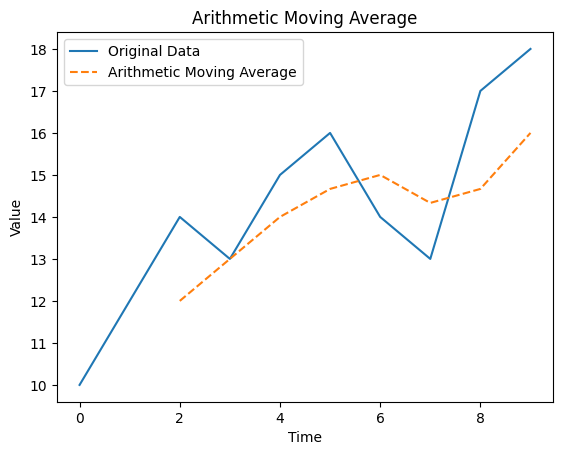

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Example time series data
data = [10, 12, 14, 13, 15, 16, 14, 13, 17, 18]
df = pd.DataFrame({"Value": data})
# Calculate 3-point moving average
df["AMA"] = df["Value"].rolling(window=3).mean()
# Plot
plt.plot(df["Value"], label="Original Data")
plt.plot(df["AMA"], label="Arithmetic Moving Average", linestyle="--")
plt.title("Arithmetic Moving Average")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.savefig("Arithmetic Moving Average.png")
plt.show()

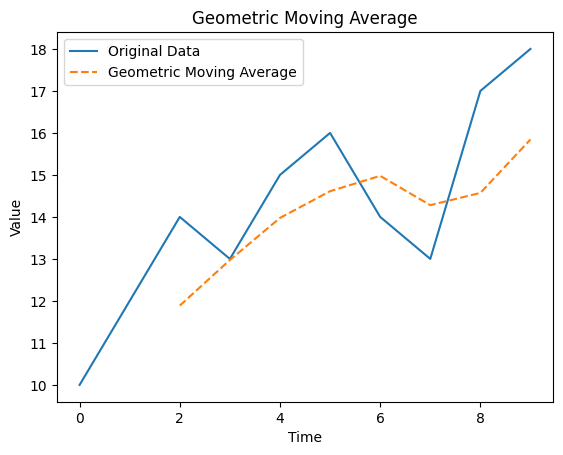

In [5]:
import numpy as np


# Calculate 3-point geometric moving average
def geometric_moving_average(series, window):
    return series.rolling(window).apply(lambda x: np.prod(x) ** (1 / window), raw=True)


df["GMA"] = geometric_moving_average(df["Value"], window=3)
# Plot
plt.plot(df["Value"], label="Original Data")
plt.plot(df["GMA"], label="Geometric Moving Average", linestyle="--")
plt.title("Geometric Moving Average")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.savefig("Geometric Moving Average.png")
plt.show()

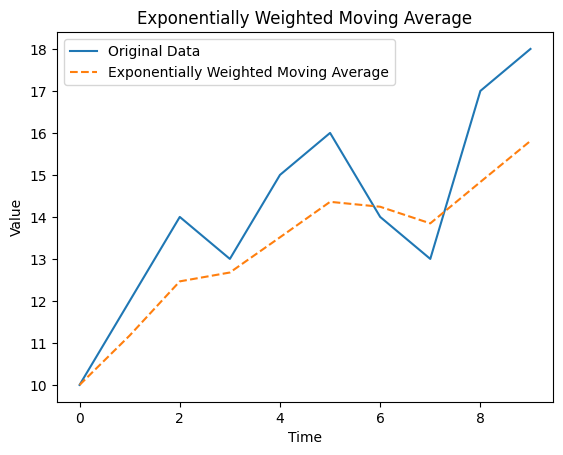

In [7]:
# Calculate exponentially weighted moving average
df["EWMA"] = df["Value"].ewm(alpha=0.3).mean()
# Plot
plt.plot(df["Value"], label="Original Data")
plt.plot(df["EWMA"], label="Exponentially Weighted Moving Average", linestyle="--")
plt.title("Exponentially Weighted Moving Average")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.savefig("Exponentially Weighted Moving Average.png")
plt.show()

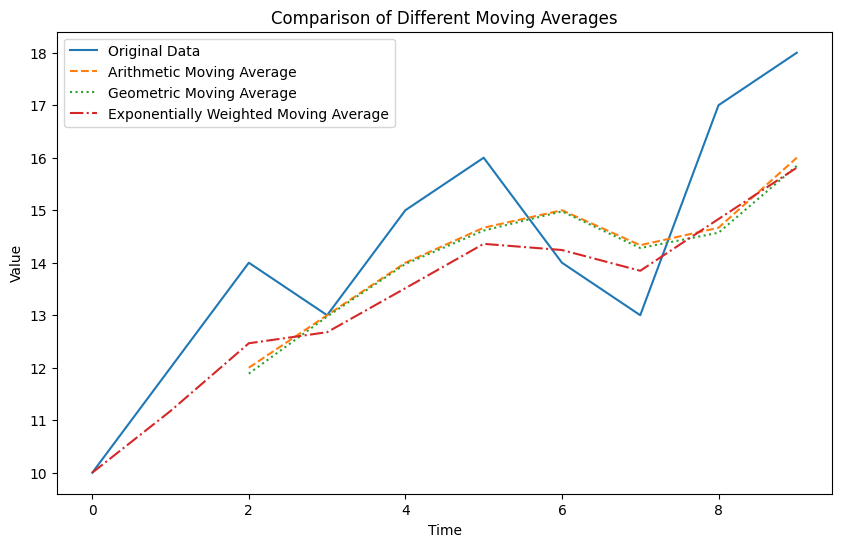

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Example time series data
data = [10, 12, 14, 13, 15, 16, 14, 13, 17, 18]
df = pd.DataFrame({"Value": data})

# Calculate all three moving averages
# 1. Arithmetic Moving Average
df["AMA"] = df["Value"].rolling(window=3).mean()


# 2. Geometric Moving Average
def geometric_moving_average(series, window):
    return series.rolling(window).apply(lambda x: np.prod(x) ** (1 / window), raw=True)


df["GMA"] = geometric_moving_average(df["Value"], window=3)

# 3. Exponentially Weighted Moving Average
df["EWMA"] = df["Value"].ewm(alpha=0.3).mean()

# Create single plot with all three moving averages
plt.figure(figsize=(10, 6))
plt.plot(df["Value"], label="Original Data")
plt.plot(df["AMA"], label="Arithmetic Moving Average", linestyle="--")
plt.plot(df["GMA"], label="Geometric Moving Average", linestyle=":")
plt.plot(df["EWMA"], label="Exponentially Weighted Moving Average", linestyle="-.")

plt.title("Comparison of Different Moving Averages")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()

plt.savefig("Combined_Moving_Averages.png")
plt.show()

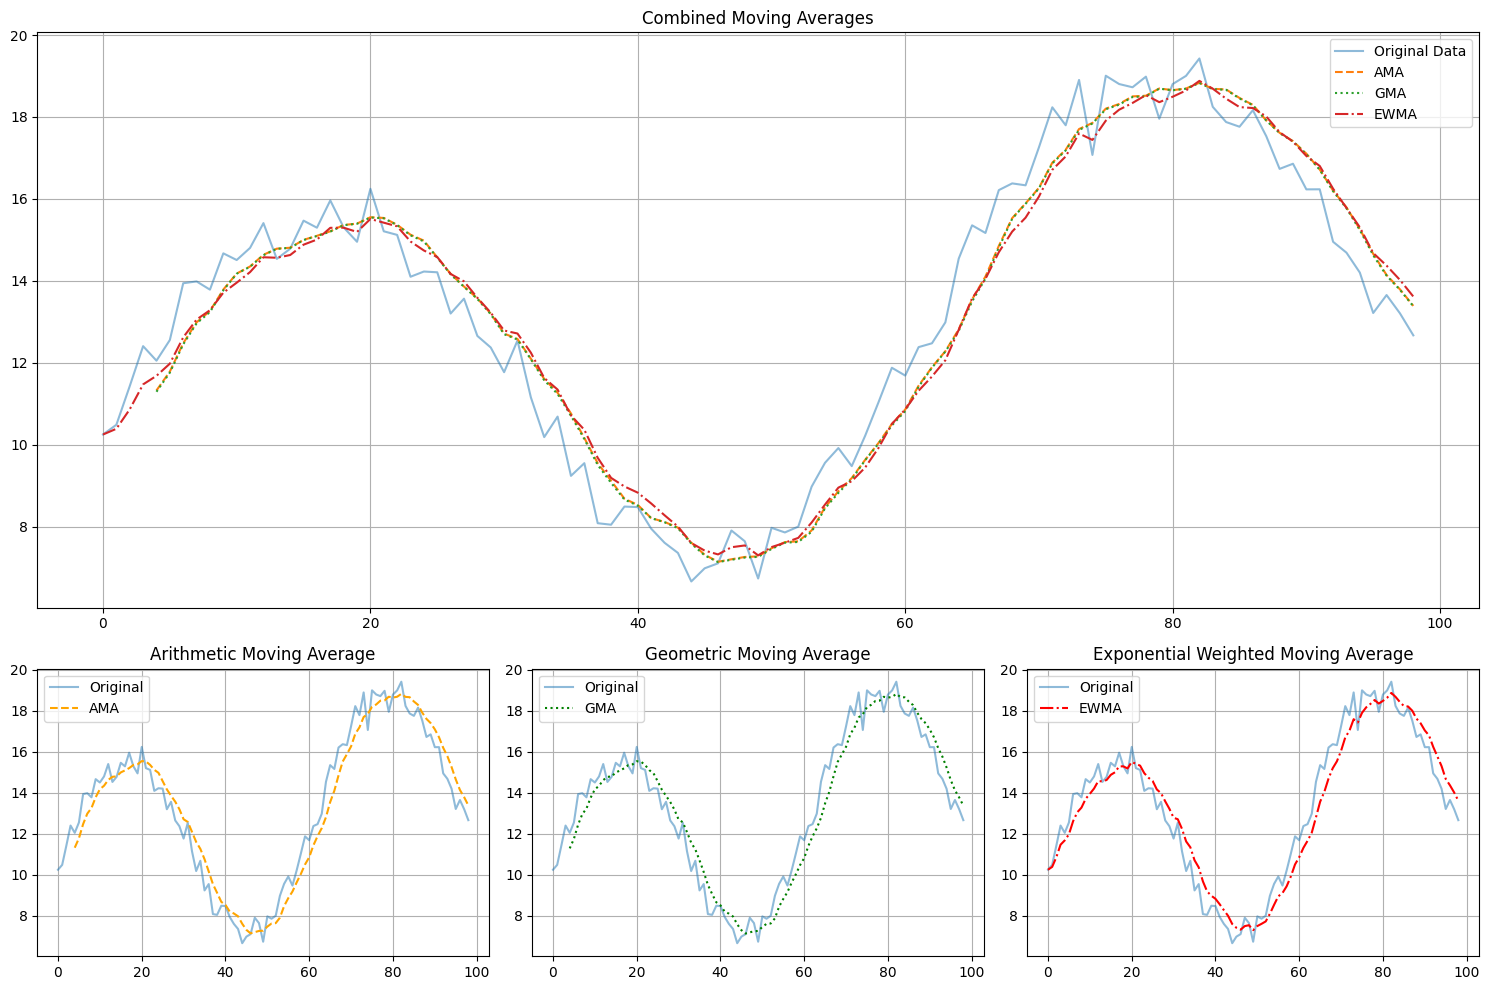

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec

# Generate more realistic simulated data
np.random.seed(42)
n_points = 100
time = np.linspace(0, 10, n_points)
# Creating a more interesting pattern with some noise and seasonality
base = 10 + np.sin(time) * 5
trend = time * 0.5
noise = np.random.normal(0, 0.5, n_points)
data = base + trend + noise

df = pd.DataFrame({"Value": data})


# Calculate moving averages
def geometric_moving_average(series, window):
    return series.rolling(window).apply(lambda x: np.prod(x) ** (1 / window), raw=True)


window_size = 5
df["AMA"] = df["Value"].rolling(window=window_size).mean()
df["GMA"] = geometric_moving_average(df["Value"], window=window_size)
df["EWMA"] = df["Value"].ewm(alpha=0.3).mean()

# Set up the figure and animation
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, height_ratios=[2, 1])


def animate(frame):
    plt.clf()

    # Main plot (top)
    ax_main = plt.subplot(gs[0, :])
    ax_main.plot(df["Value"][:frame], label="Original Data", alpha=0.5)
    ax_main.plot(df["AMA"][:frame], label="AMA", linestyle="--")
    ax_main.plot(df["GMA"][:frame], label="GMA", linestyle=":")
    ax_main.plot(df["EWMA"][:frame], label="EWMA", linestyle="-.")
    ax_main.set_title("Combined Moving Averages")
    ax_main.legend()
    ax_main.grid(True)

    # AMA subplot
    ax1 = plt.subplot(gs[1, 0])
    ax1.plot(df["Value"][:frame], label="Original", alpha=0.5)
    ax1.plot(df["AMA"][:frame], label="AMA", color="orange", linestyle="--")
    ax1.set_title("Arithmetic Moving Average")
    ax1.legend()
    ax1.grid(True)

    # GMA subplot
    ax2 = plt.subplot(gs[1, 1])
    ax2.plot(df["Value"][:frame], label="Original", alpha=0.5)
    ax2.plot(df["GMA"][:frame], label="GMA", color="green", linestyle=":")
    ax2.set_title("Geometric Moving Average")
    ax2.legend()
    ax2.grid(True)

    # EWMA subplot
    ax3 = plt.subplot(gs[1, 2])
    ax3.plot(df["Value"][:frame], label="Original", alpha=0.5)
    ax3.plot(df["EWMA"][:frame], label="EWMA", color="red", linestyle="-.")
    ax3.set_title("Exponential Weighted Moving Average")
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout()


# Create animation
anim = FuncAnimation(
    fig,
    animate,
    frames=range(window_size, len(df)),
    interval=100,  # 100ms between frames
    repeat=False,
)

# Save animation
anim.save("moving_averages_animation.gif", writer="pillow")
plt.show()

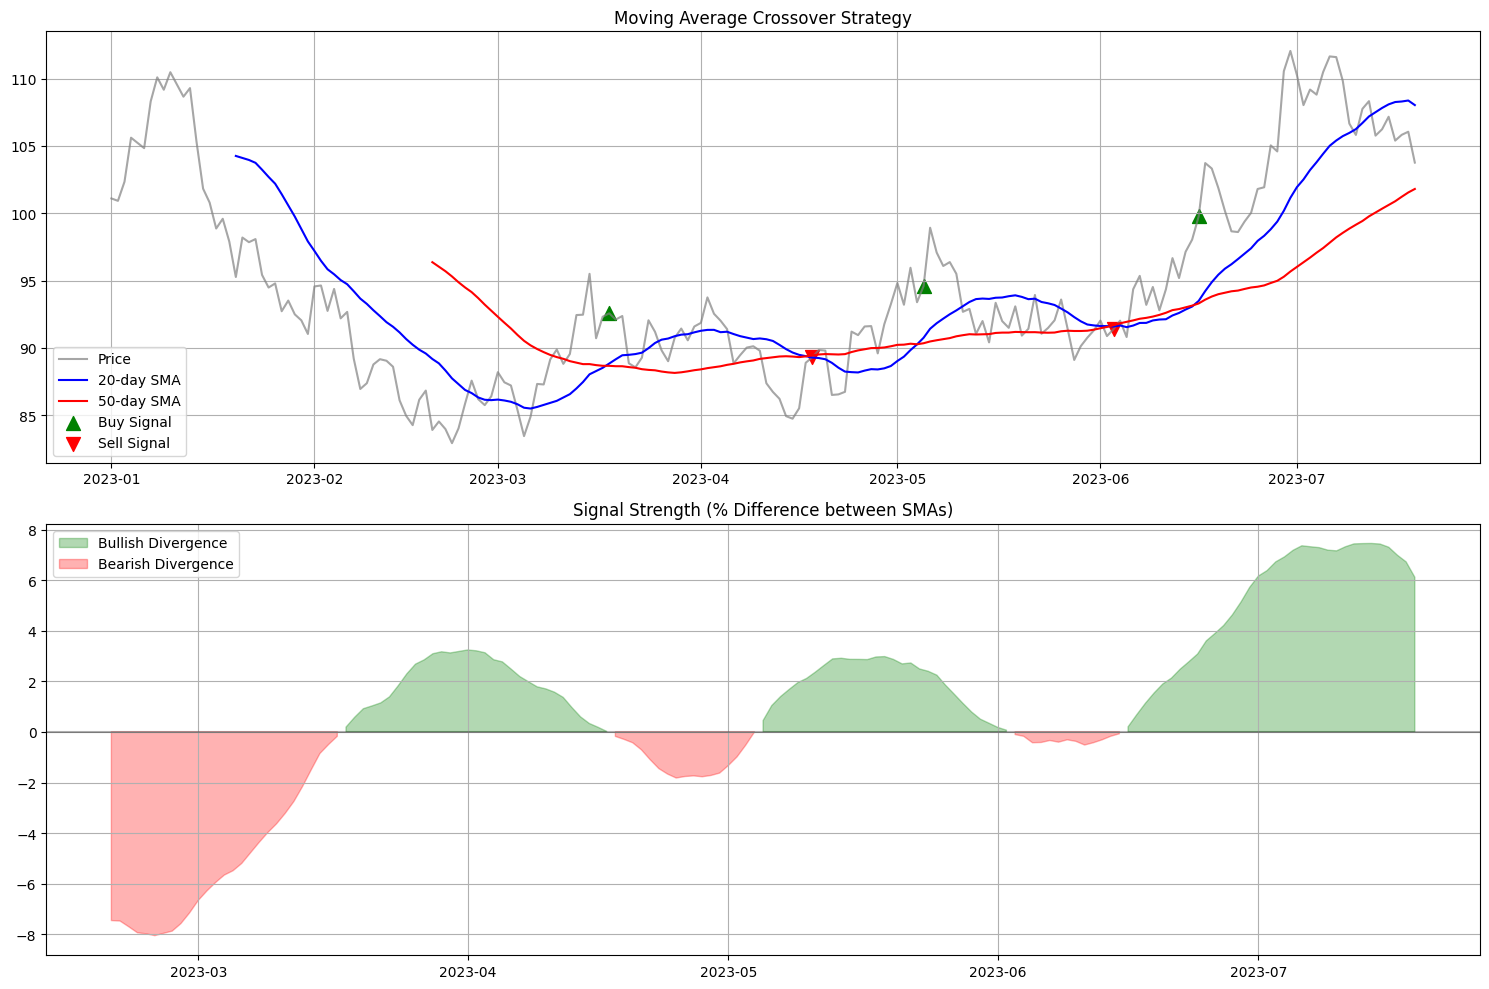


Trading Summary:
Number of Buy Signals: 3
Number of Sell Signals: 2
Strategy Total Return: -25.70%


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Generate realistic price data that mimics stock market behavior
def generate_stock_data(n_days, volatility=0.02, drift=0.001):
    np.random.seed(42)
    returns = np.random.normal(loc=drift, scale=volatility, size=n_days)
    price = 100 * np.exp(np.cumsum(returns))
    return price


# Generate 200 days of data
n_days = 200
dates = pd.date_range(start="2023-01-01", periods=n_days, freq="D")
prices = generate_stock_data(n_days)
df = pd.DataFrame({"Date": dates, "Price": prices})

# Calculate short-term (20-day) and long-term (50-day) moving averages
df["SMA20"] = df["Price"].rolling(window=20).mean()
df["SMA50"] = df["Price"].rolling(window=50).mean()

# Generate trading signals
df["Signal"] = 0
df.loc[df["SMA20"] > df["SMA50"], "Signal"] = 1  # Buy signal
df.loc[df["SMA20"] < df["SMA50"], "Signal"] = -1  # Sell signal

# Detect crossover points
df["Crossover"] = df[
    "Signal"
].diff()  # Will be 2 for buy crossover, -2 for sell crossover

# Create the visualization
plt.figure(figsize=(15, 10))

# Main price and moving average plot
plt.subplot(2, 1, 1)
plt.plot(df["Date"], df["Price"], label="Price", alpha=0.7, color="gray")
plt.plot(df["Date"], df["SMA20"], label="20-day SMA", color="blue")
plt.plot(df["Date"], df["SMA50"], label="50-day SMA", color="red")

# Plot buy signals
buy_signals = df[df["Crossover"] == 2]
plt.scatter(
    buy_signals["Date"],
    buy_signals["Price"],
    marker="^",
    color="green",
    s=100,
    label="Buy Signal",
)

# Plot sell signals
sell_signals = df[df["Crossover"] == -2]
plt.scatter(
    sell_signals["Date"],
    sell_signals["Price"],
    marker="v",
    color="red",
    s=100,
    label="Sell Signal",
)

plt.title("Moving Average Crossover Strategy")
plt.legend()
plt.grid(True)

# Signal strength plot
plt.subplot(2, 1, 2)
plt.fill_between(
    df["Date"],
    (df["SMA20"] - df["SMA50"]) / df["SMA50"] * 100,
    0,
    where=(df["SMA20"] - df["SMA50"]) > 0,
    color="green",
    alpha=0.3,
    label="Bullish Divergence",
)
plt.fill_between(
    df["Date"],
    (df["SMA20"] - df["SMA50"]) / df["SMA50"] * 100,
    0,
    where=(df["SMA20"] - df["SMA50"]) < 0,
    color="red",
    alpha=0.3,
    label="Bearish Divergence",
)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.title("Signal Strength (% Difference between SMAs)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("moving_average_crossover.png")
plt.show()

# Print trading summary
buy_signals_count = len(buy_signals)
sell_signals_count = len(sell_signals)
print("\nTrading Summary:")
print(f"Number of Buy Signals: {buy_signals_count}")
print(f"Number of Sell Signals: {sell_signals_count}")

# Calculate strategy performance (fixed version)
df["Strategy_Returns"] = df["Signal"].shift(1) * df["Price"].pct_change()
total_return = (1 + df["Strategy_Returns"].fillna(0)).prod() - 1
print(f"Strategy Total Return: {total_return:.2%}")